In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [6]:
df = pd.read_csv("F:/Jupyter Projects/Phitron AL ML/Dataset/bangladesh_student_performance.csv")
df.head()

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94


In [7]:
df.shape

(2018, 16)

In [8]:
df.isnull().sum()

date            0
gender          0
age             0
address         0
famsize         0
Pstatus         0
M_Edu           0
F_Edu           0
M_Job           0
F_Job           0
relationship    0
smoker          0
tuition_fee     0
time_friends    0
ssc_result      0
hsc_result      0
dtype: int64

In [9]:
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

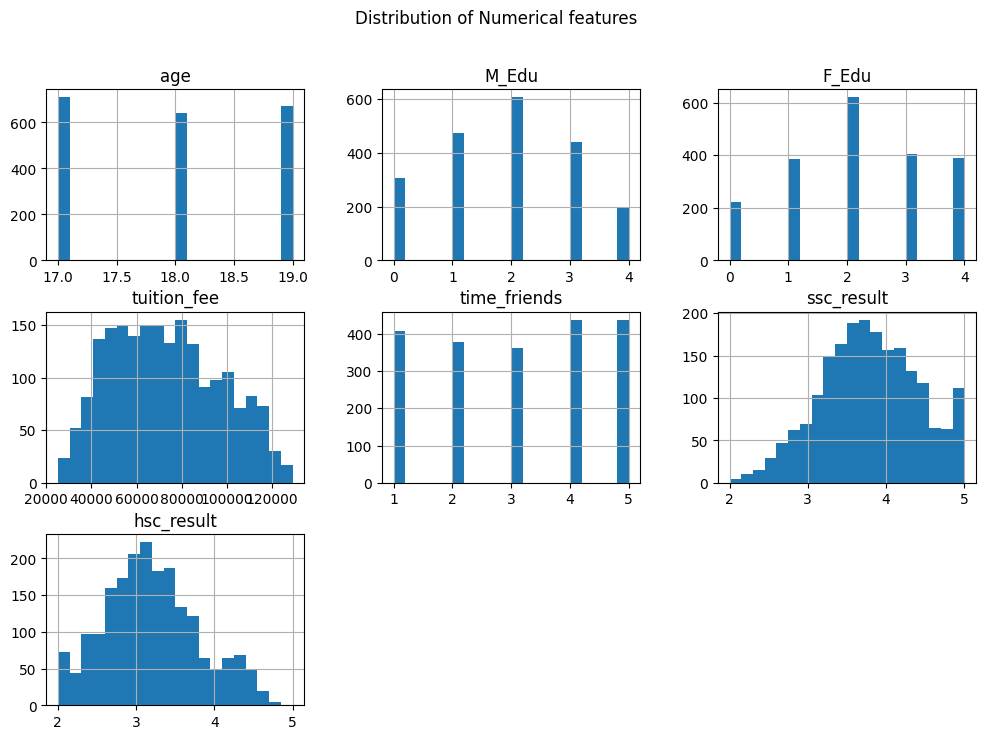

In [12]:
df.hist(figsize = (12,8), bins = 20)
plt.suptitle('Distribution of Numerical features')
plt.show()

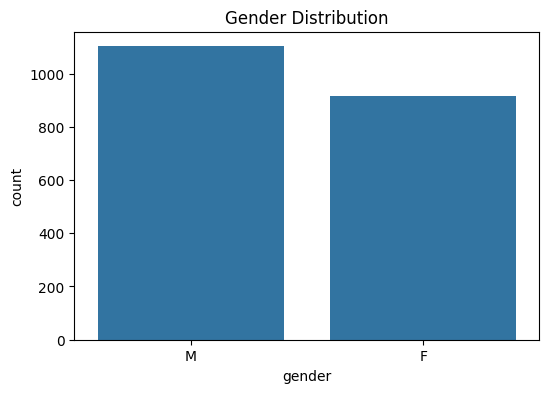

In [13]:
plt.figure(figsize = (6,4))
sns.countplot(
    data = df,
    x = 'gender'
)
plt.title('Gender Distribution')
plt.show()

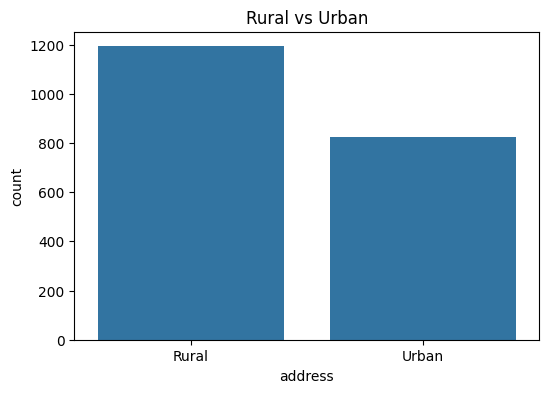

In [15]:
plt.figure(figsize = (6,4))
sns.countplot(
    data = df,
    x = 'address'
)
plt.title('Rural vs Urban')
plt.show()

In [16]:
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

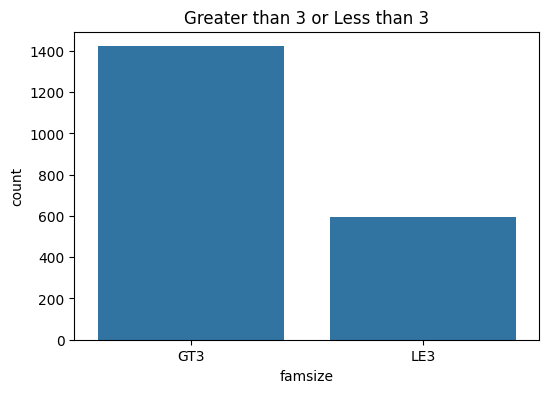

In [18]:
plt.figure(figsize = (6,4))
sns.countplot(
    data = df,
    x = 'famsize'
)
plt.title('Greater than 3 or Less than 3')
plt.show()

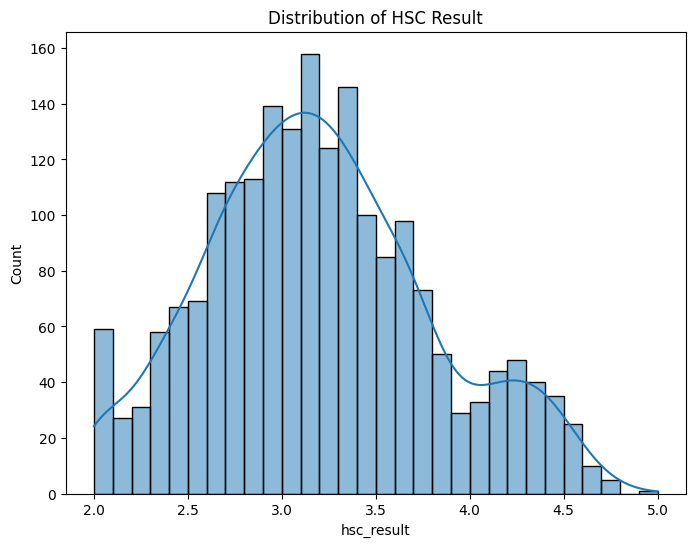

In [20]:
plt.figure( figsize = (8,6) )
sns.histplot(
    data = df,
    x = 'hsc_result',
    bins = 30,
    kde = True
)
plt.title('Distribution of HSC Result')
plt.show()

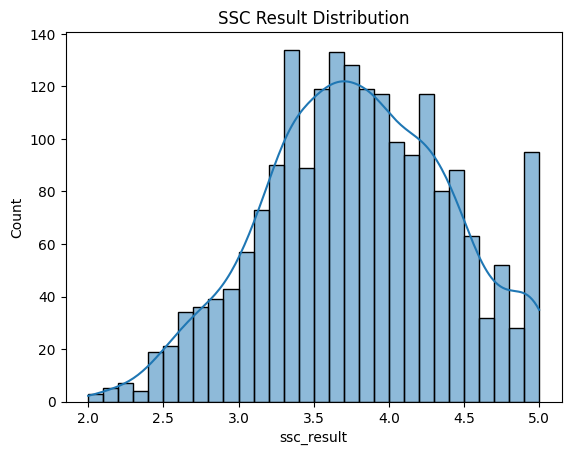

In [22]:
sns.histplot(
    data = df,
    x = 'ssc_result',
    bins = 30,
    kde = True
)

plt.title('SSC Result Distribution')
plt.show()

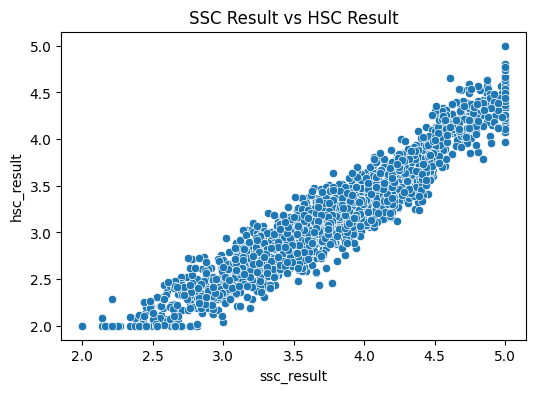

In [21]:
plt.figure( figsize = (6,4) )
sns.scatterplot(
    data = df,
    x = 'ssc_result',
    y = 'hsc_result'
)
plt.title('SSC Result vs HSC Result')
plt.show()

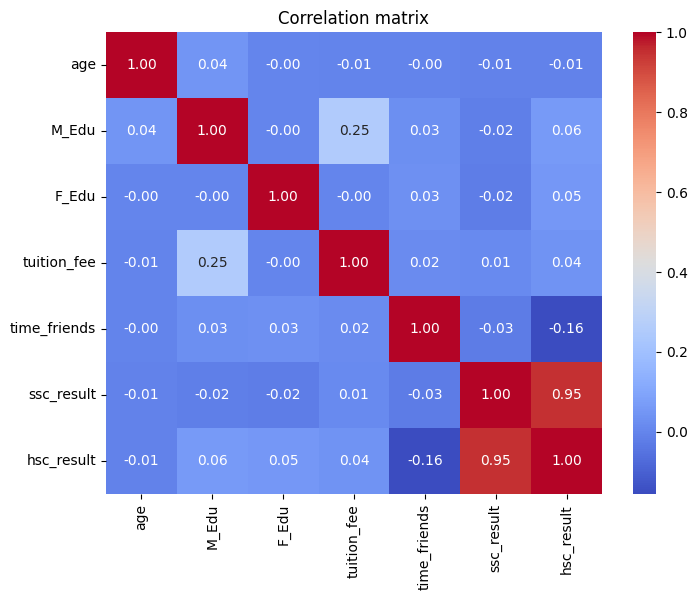

In [26]:
plt.figure( figsize = (8,6) )
sns.heatmap(
    df.select_dtypes(include = np.number).corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt = ".2f"
)
plt.title("Correlation matrix")
plt.show()

In [29]:
X = df.drop(columns = ['hsc_result','date'])
y = pd.DataFrame(df.hsc_result)

X

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
0,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22
1,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47
2,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32
3,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57
4,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57
2014,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05
2015,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93
2016,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34


In [30]:
y

,hsc_result
0,3.72
1,2.62
2,2.56
3,4.17
4,3.94
...,...
2013,3.18
2014,3.13
2015,3.15
2016,2.83


In [31]:
numeric_features = X.select_dtypes( include = ['int64','float64']).columns
categorical_features = X.select_dtypes( include = ['object']).columns

In [32]:
numeric_features

Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')

In [33]:
categorical_features

Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object')

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42
)

In [35]:
X_train

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
746,M,19,Rural,LE3,Together,2,2,Other,Services,No,No,49318,3,4.95
1381,M,17,Urban,GT3,Together,0,1,Health,Farmer,No,Yes,88032,5,2.68
240,F,17,Urban,GT3,Together,4,3,Other,Services,No,No,116230,4,3.75
1646,M,18,Urban,LE3,Apart,2,1,Other,Business,No,No,79334,3,3.70
1460,M,18,Rural,GT3,Apart,4,3,At_home,Farmer,No,No,80248,2,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,F,18,Rural,GT3,Together,2,2,At_home,Health,No,No,50003,1,3.83
1294,F,19,Urban,LE3,Together,2,3,At_home,Farmer,Yes,No,110895,2,3.30
860,F,19,Rural,GT3,Together,0,2,Health,Farmer,No,No,51576,1,5.00
1459,F,18,Rural,GT3,Together,2,4,Other,Services,No,No,45830,1,4.42


In [36]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743,1,3.88
526,M,19,Rural,GT3,Together,4,3,At_home,Business,No,No,58678,5,4.36
393,F,18,Urban,GT3,Together,2,1,Services,Services,No,No,115832,3,4.47
1789,M,17,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781,1,4.43
433,M,19,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345,4,3.47
693,M,19,Urban,GT3,Together,1,2,Health,Business,No,No,85346,4,2.96
1494,F,18,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638,1,3.76
921,M,19,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804,2,4.18


In [38]:
num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer( strategy = 'most_frequent' )),
    ('encoder', OneHotEncoder( handle_unknown = 'ignore' ))
])

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat',cat_transformer, categorical_features)
    ]
)

In [40]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [ ]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [42]:
ETA = 0.001
MAX_ITER = 3000
ALPHA = 0.0001

In [46]:
sgd_pipeline = Pipeline( steps = [
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(
        loss = 'squared_error',
        penalty = 'l2',
        alpha = ALPHA,
        learning_rate = 'constant',
        eta0 = ETA,
        max_iter = MAX_ITER,
        random_state = 42
    ))
])

In [47]:
def evaluate_model(model, model_name):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
    mae_test = mean_absolute_error(y_test, test_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Train R2 : {r2_train:.4f}")
    print(f"Test R2  : {r2_test:.4f}")
    print(f"RMSE     : {rmse_test:.4f}")
    print(f"MAE      : {mae_test:.4f}")

    return r2_test, rmse_test, mae_test

In [48]:
lr_results = evaluate_model(lr_pipeline, "Linear Regression")
sgd_results = evaluate_model(sgd_pipeline, 'SGD Regressor')


Linear Regression
----------------------------------------
Train R2 : 0.9466
Test R2  : 0.9459
RMSE     : 0.1424
MAE      : 0.1114

SGD Regressor
----------------------------------------
Train R2 : 0.9447
Test R2  : 0.9453
RMSE     : 0.1432
MAE      : 0.1116


In [50]:
print('\nCross Validation (Linear Regression)')
print('-' * 40)
cv_scores = cross_val_score(lr_pipeline, X, y, cv = 5, scoring = 'r2')
print('Scores: ', cv_scores)
print(f"Average CV: {cv_scores.mean():.4f}")


Cross Validation (Linear Regression)
----------------------------------------
Scores:  [0.94815437 0.95301409 0.93902546 0.94315463 0.94180106]
Average CV: 0.9450


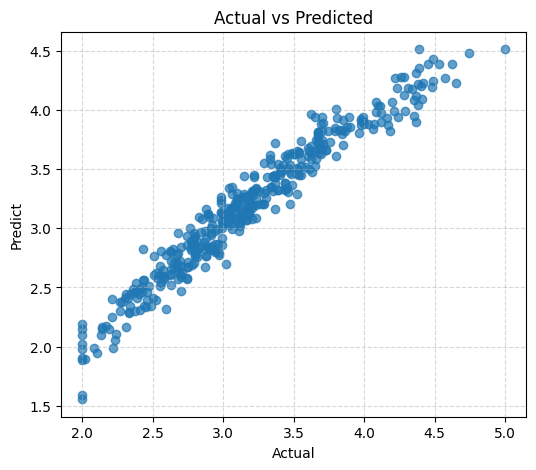

In [51]:
y_pred = lr_pipeline.predict(X_test)

plt.figure( figsize = (6,5) )
plt.scatter(y_test, y_pred, alpha = 0.7)
plt.xlabel('Actual')
plt.ylabel('Predict')
plt.title('Actual vs Predicted')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()